# 05 · Insight Extraction

Strong, end-to-end insight extraction across **all four** trained models:

| Model | From notebook | Role here |
|---|---|---|
| Logistic Regression + TF-IDF | `04_baseline_model` | Word-level interpretability (coefficients) |
| Complement Naive Bayes + TF-IDF | `04_baseline_model` | Probabilistic baseline reference |
| BiLSTM + Word2Vec | `03_modelling` | Sequence model for comparison |
| BERT MLP (`all-MiniLM-L6-v2`) | `03_modelling` | Semantic model for comparison |

**Why this design.** Deep models (LSTM, BERT) are black-boxes at the word level — they don't expose per-word coefficients. So we use the **Logistic Regression model** (which is linear over TF-IDF features) as our interpretability lens, and we use **all four models' predictions** for agreement / disagreement / confidence insights. This gives the strongest possible insight story without making up importance scores the architectures can't actually provide.



## 1 · Setup & Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, re, warnings
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


In [3]:
# ── Paths (match the conventions from notebooks 03 & 04) ──────────
DRIVE_ROOT     = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURES_DIR   = f'{DRIVE_ROOT}/data/features'
PROCESSED_DIR  = f'{DRIVE_ROOT}/data/processed'
BASELINE_DIR   = f'{DRIVE_ROOT}/models/baseline_models'
MODELS_DIR     = f'{DRIVE_ROOT}/models'
OUTPUT_DIR     = f'{DRIVE_ROOT}/models/insights'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Outputs will be written to: {OUTPUT_DIR}')

Outputs will be written to: /content/drive/MyDrive/SmartReviewAnalyzer/models/insights


## 2 · Load Artefacts (defensive)

Every load is wrapped so the notebook keeps running even if a single artefact is missing — at the end we print a summary of what was loaded so issues are visible immediately.

In [4]:
def safe_load(label, loader):
    """Run `loader()` and report. Returns (object_or_None, status_str)."""
    try:
        obj = loader()
        return obj, 'OK'
    except FileNotFoundError as e:
        return None, f'MISSING: {e}'
    except Exception as e:
        return None, f'ERROR: {type(e).__name__}: {e}'

loaded = {}

# ── Labels & TF-IDF features ──
labels, st = safe_load('labels.npz',
                       lambda: np.load(f'{FEATURES_DIR}/labels.npz'))
loaded['labels.npz'] = st
y_train = labels['y_train'] if labels is not None else None
y_test  = labels['y_test']  if labels is not None else None

X_train_tfidf, st = safe_load('X_train_tfidf',
                              lambda: sp.load_npz(f'{FEATURES_DIR}/X_train_tfidf.npz'))
loaded['X_train_tfidf.npz'] = st

X_test_tfidf, st = safe_load('X_test_tfidf',
                             lambda: sp.load_npz(f'{FEATURES_DIR}/X_test_tfidf.npz'))
loaded['X_test_tfidf.npz'] = st

tfidf, st = safe_load('tfidf_vectorizer',
                      lambda: joblib.load(f'{FEATURES_DIR}/tfidf_vectorizer.joblib'))
loaded['tfidf_vectorizer.joblib'] = st

# ── Baseline models ──
lr_tfidf, st = safe_load('lr_tfidf',
                         lambda: joblib.load(f'{BASELINE_DIR}/lr_tfidf.joblib'))
loaded['lr_tfidf.joblib'] = st

nb_tfidf, st = safe_load('nb_tfidf',
                         lambda: joblib.load(f'{BASELINE_DIR}/nb_tfidf.joblib'))
loaded['nb_tfidf.joblib'] = st

# ── Deep-model predictions (saved by notebook 03) ──
y_pred_lstm, st  = safe_load('y_pred_lstm',
                             lambda: np.load(f'{MODELS_DIR}/y_pred_lstm.npy'))
loaded['y_pred_lstm.npy'] = st

y_proba_lstm, st = safe_load('y_proba_lstm',
                             lambda: np.load(f'{MODELS_DIR}/y_proba_lstm.npy'))
loaded['y_proba_lstm.npy'] = st

y_pred_bert, st  = safe_load('y_pred_bert',
                             lambda: np.load(f'{MODELS_DIR}/y_pred_bert.npy'))
loaded['y_pred_bert.npy'] = st

y_proba_bert, st = safe_load('y_proba_bert',
                             lambda: np.load(f'{MODELS_DIR}/y_proba_bert.npy'))
loaded['y_proba_bert.npy'] = st

# ── Raw processed text (for pattern mining) ──
df_train_raw, st = safe_load('preprocessed_train.csv',
                             lambda: pd.read_csv(f'{PROCESSED_DIR}/preprocessed_train.csv'))
loaded['preprocessed_train.csv'] = st

df_test_raw, st = safe_load('preprocessed_test.csv',
                            lambda: pd.read_csv(f'{PROCESSED_DIR}/preprocessed_test.csv'))
loaded['preprocessed_test.csv'] = st

print('\n── Load summary ───────────────────────────────────────')
for k, v in loaded.items():
    mark = '✓' if v == 'OK' else '✗'
    print(f'  {mark} {k:<35s} {v}')


── Load summary ───────────────────────────────────────
  ✓ labels.npz                          OK
  ✓ X_train_tfidf.npz                   OK
  ✓ X_test_tfidf.npz                    OK
  ✓ tfidf_vectorizer.joblib             OK
  ✓ lr_tfidf.joblib                     OK
  ✓ nb_tfidf.joblib                     OK
  ✓ y_pred_lstm.npy                     OK
  ✓ y_proba_lstm.npy                    OK
  ✓ y_pred_bert.npy                     OK
  ✓ y_proba_bert.npy                    OK
  ✓ preprocessed_train.csv              OK
  ✓ preprocessed_test.csv               OK


In [5]:
# ── Compute baseline predictions from loaded models (so we have all 4 in one place) ──
# These are reproduced here rather than loaded because notebook 04 doesn't save them as .npy.

if lr_tfidf is not None and X_test_tfidf is not None:
    y_pred_lr   = lr_tfidf.predict(X_test_tfidf)
    y_proba_lr  = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]
    print(f'LR  predictions: {y_pred_lr.shape}, proba range [{y_proba_lr.min():.3f}, {y_proba_lr.max():.3f}]')
else:
    y_pred_lr = y_proba_lr = None
    print('LR predictions unavailable (model or features missing).')

if nb_tfidf is not None and X_test_tfidf is not None:
    y_pred_nb   = nb_tfidf.predict(X_test_tfidf)
    y_proba_nb  = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]
    print(f'NB  predictions: {y_pred_nb.shape}, proba range [{y_proba_nb.min():.3f}, {y_proba_nb.max():.3f}]')
else:
    y_pred_nb = y_proba_nb = None
    print('NB predictions unavailable (model or features missing).')

LR  predictions: (39972,), proba range [0.000, 1.000]
NB  predictions: (39972,), proba range [0.000, 1.000]


In [6]:
# ── Hard gate: we need at least labels + train data + LR to do meaningful insight extraction ──
assert y_train is not None,       'labels.npz failed to load — check FEATURES_DIR.'
assert df_train_raw is not None,  'preprocessed_train.csv failed to load — check PROCESSED_DIR.'
assert lr_tfidf is not None,      'LR model failed to load — run notebook 04 first.'
assert tfidf is not None,         'TF-IDF vectoriser failed to load — check FEATURES_DIR.'

# Soft check: warn if any deep-model predictions are missing
missing_deep = [name for name, arr in [
    ('y_pred_lstm', y_pred_lstm), ('y_proba_lstm', y_proba_lstm),
    ('y_pred_bert', y_pred_bert), ('y_proba_bert', y_proba_bert),
] if arr is None]
if missing_deep:
    print('⚠  Some deep-model artefacts are missing:', missing_deep)
    print('   Sections that need them will be skipped automatically.')
else:
    print('✓ All 4 models available — full insight pipeline will run.')

✓ All 4 models available — full insight pipeline will run.


## 3 · Sentiment Distribution

In [7]:
pos_train = int((y_train == 1).sum())
neg_train = int((y_train == 0).sum())
total_train = int(len(y_train))

print('═'*60)
print('  SENTIMENT DISTRIBUTION (TRAIN)')
print('═'*60)
print(f'  Positive : {pos_train:>8,}  ({pos_train/total_train*100:5.2f}%)')
print(f'  Negative : {neg_train:>8,}  ({neg_train/total_train*100:5.2f}%)')
print(f'  Total    : {total_train:>8,}')

if y_test is not None:
    pos_test = int((y_test == 1).sum()); neg_test = int((y_test == 0).sum())
    print(f'\n  Test set : pos={pos_test:,}  neg={neg_test:,}  total={len(y_test):,}')

════════════════════════════════════════════════════════════
  SENTIMENT DISTRIBUTION (TRAIN)
════════════════════════════════════════════════════════════
  Positive :  259,844  (50.01%)
  Negative :  259,731  (49.99%)
  Total    :  519,575

  Test set : pos=19,991  neg=19,981  total=39,972


## 4 · Top Keywords per Class (Logistic Regression coefficients)

Because LR is linear over TF-IDF features, the sign and magnitude of each coefficient give an honest, principled measure of which words push a prediction toward each class. Deep models don't expose this directly — that's why we use LR here.

In [8]:
feature_names   = np.array(tfidf.get_feature_names_out())
lr_coefficients = lr_tfidf.coef_[0]

assert len(feature_names) == len(lr_coefficients), (
    f'Feature/coefficient size mismatch: {len(feature_names)} vs {len(lr_coefficients)}. '
    f'The TF-IDF vectoriser and LR model were trained on different vocabularies.'
)

TOP_K = 20
top_pos_idx = np.argsort(lr_coefficients)[-TOP_K:][::-1]
top_neg_idx = np.argsort(lr_coefficients)[:TOP_K]

top_positive_words = feature_names[top_pos_idx]
top_negative_words = feature_names[top_neg_idx]

print(f'\nTop {TOP_K} POSITIVE keywords:')
for i, (w, c) in enumerate(zip(top_positive_words, lr_coefficients[top_pos_idx]), 1):
    print(f'  {i:2d}. {w:<25s}  coef={c:+.4f}')

print(f'\nTop {TOP_K} NEGATIVE keywords:')
for i, (w, c) in enumerate(zip(top_negative_words, lr_coefficients[top_neg_idx]), 1):
    print(f'  {i:2d}. {w:<25s}  coef={c:+.4f}')


Top 20 POSITIVE keywords:
   1. great                      coef=+15.9573
   2. delicious                  coef=+14.3976
   3. not disappointed           coef=+13.3430
   4. amaze                      coef=+12.4106
   5. love                       coef=+12.2901
   6. awesome                    coef=+12.0384
   7. best                       coef=+11.6086
   8. excellent                  coef=+11.4299
   9. perfect                    coef=+10.6076
  10. fantastic                  coef=+9.8452
  11. not disappoint             coef=+9.7909
  12. favorite                   coef=+9.3403
  13. go wrong                   coef=+8.9531
  14. not bad                    coef=+8.4792
  15. amazing                    coef=+8.3723
  16. incredible                 coef=+8.2070
  17. yummy                      coef=+7.8895
  18. definitely                 coef=+7.7524
  19. good                       coef=+7.6200
  20. never bad                  coef=+7.5341

Top 20 NEGATIVE keywords:
   1. not worth  

## 5 · Complaint & Praise Patterns

Domain-specific keyword groups. Counts mentions of each group in negative and positive training reviews.

In [9]:
TEXT_COL = 'cleaned_text_tfidf'
assert TEXT_COL in df_train_raw.columns, (
    f"Column '{TEXT_COL}' not found in preprocessed_train.csv. "
    f"Available columns: {list(df_train_raw.columns)}"
)
assert 'binary_label' in df_train_raw.columns, (
    f"Column 'binary_label' not found in preprocessed_train.csv. "
    f"Available columns: {list(df_train_raw.columns)}"
)

neg_reviews = df_train_raw[df_train_raw['binary_label'] == 0][TEXT_COL].fillna('')
pos_reviews = df_train_raw[df_train_raw['binary_label'] == 1][TEXT_COL].fillna('')

complaint_patterns = {
    'Service speed'  : ['slow', 'wait', 'long wait', 'forever', 'hour wait'],
    'Food quality'   : ['cold', 'bad food', 'terrible food', 'tasteless', 'bland'],
    'Staff attitude' : ['rude', 'unfriendly', 'unprofessional', 'ignore'],
    'Cleanliness'    : ['dirty', 'filthy', 'gross', 'disgusting'],
    'Price/Value'    : ['expensive', 'overpriced', 'waste money', 'not worth'],
}

praise_patterns = {
    'Food quality'   : ['delicious', 'amazing food', 'great food', 'best', 'fresh'],
    'Service'        : ['friendly', 'attentive', 'great service', 'excellent service'],
    'Atmosphere'     : ['cozy', 'atmosphere', 'ambiance', 'nice place', 'love'],
    'Value'          : ['worth', 'reasonable', 'affordable', 'good price'],
    'Recommendation' : ['recommend', 'come back', 'definitely return', 'must try'],
}

def count_pattern(series, keywords):
    text = ' '.join(series.tolist()).lower()
    return sum(text.count(kw) for kw in keywords)

neg_pattern_counts = {k: count_pattern(neg_reviews, v) for k, v in complaint_patterns.items()}
pos_pattern_counts = {k: count_pattern(pos_reviews, v) for k, v in praise_patterns.items()}

print('Complaint patterns (in NEGATIVE reviews):')
for k, v in sorted(neg_pattern_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<18s} {v:>8,} mentions')

print('\nPraise patterns (in POSITIVE reviews):')
for k, v in sorted(pos_pattern_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<18s} {v:>8,} mentions')

Complaint patterns (in NEGATIVE reviews):
  Service speed       156,065 mentions
  Food quality         41,760 mentions
  Staff attitude       35,846 mentions
  Price/Value          27,364 mentions
  Cleanliness          22,540 mentions

Praise patterns (in POSITIVE reviews):
  Food quality        149,935 mentions
  Atmosphere          117,153 mentions
  Service              63,546 mentions
  Recommendation       53,343 mentions
  Value                38,634 mentions


## 6 · Review-Length vs. Sentiment

Does length correlate with sentiment? A surprisingly useful sanity check.

In [10]:
df_train_raw['_n_words'] = df_train_raw[TEXT_COL].fillna('').str.split().str.len()

length_stats = df_train_raw.groupby('binary_label')['_n_words'].agg(['mean', 'median', 'std', 'min', 'max']).round(1)
length_stats.index = ['Negative', 'Positive']
print('Review length (in tokens) by class:')
print(length_stats.to_string())

Review length (in tokens) by class:
          mean  median   std  min   max
Negative  77.5    58.0  68.0    2   806
Positive  60.6    44.0  55.6    2  1076


## 7 · Model Agreement Analysis

Where do the 4 models agree? Where do they disagree? Disagreement reveals where the linear / sequential / semantic views of the same review pull apart.

In [11]:
have_lr   = y_pred_lr is not None
have_nb   = y_pred_nb is not None
have_lstm = y_pred_lstm is not None
have_bert = y_pred_bert is not None

models_available = [name for name, ok in [
    ('LR', have_lr), ('NB', have_nb), ('LSTM', have_lstm), ('BERT', have_bert)
] if ok]
print(f'Models available for agreement analysis: {models_available}')

# Build a long-form prediction DataFrame for whichever models are available
pred_cols = {}
if have_lr:   pred_cols['LR']   = y_pred_lr
if have_nb:   pred_cols['NB']   = y_pred_nb
if have_lstm: pred_cols['LSTM'] = y_pred_lstm
if have_bert: pred_cols['BERT'] = y_pred_bert

# All vectors must have the same length as y_test
if y_test is not None and pred_cols:
    n = len(y_test)
    for name, arr in pred_cols.items():
        assert len(arr) == n, (
            f'{name} predictions have length {len(arr)} but y_test has length {n}. '
            f'Predictions were generated on a different split — re-run the relevant notebook.'
        )

    df_preds = pd.DataFrame(pred_cols)
    df_preds['y_true'] = y_test
    print(f'\nAll prediction vectors aligned: n={n:,}')
else:
    df_preds = None
    print('No test labels or predictions available — skipping agreement analysis.')

Models available for agreement analysis: ['LR', 'NB', 'LSTM', 'BERT']

All prediction vectors aligned: n=39,972


In [12]:
if df_preds is not None and len(pred_cols) >= 2:
    model_cols = list(pred_cols.keys())

    # ── Pairwise agreement matrix (fraction of test examples where the two predict the same label) ──
    agreement = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
    for a in model_cols:
        for b in model_cols:
            agreement.loc[a, b] = float((df_preds[a] == df_preds[b]).mean())
    agreement = agreement.round(4)
    print('Pairwise prediction agreement (fraction of test set):')
    print(agreement.to_string())

    # ── How often do ALL models agree? ──
    all_same = df_preds[model_cols].nunique(axis=1) == 1
    print(f'\nAll {len(model_cols)} models agree on {all_same.sum():,} / {len(df_preds):,} examples '
          f'({all_same.mean()*100:.2f}%).')

    # ── When all models agree, how often are they right? ──
    if all_same.sum() > 0:
        unanimous_correct = (df_preds.loc[all_same, model_cols[0]] == df_preds.loc[all_same, 'y_true']).mean()
        print(f'When unanimous: correct on {unanimous_correct*100:.2f}% of those examples.')

    # ── Disagreement examples ──
    disagree_mask = ~all_same
    print(f'\nDisagreement examples: {disagree_mask.sum():,} ({disagree_mask.mean()*100:.2f}%)')
else:
    agreement = None
    print('Skipped agreement matrix (need at least 2 models).')

Pairwise prediction agreement (fraction of test set):
          LR      NB    LSTM    BERT
LR    1.0000  0.9337  0.9561  0.9062
NB    0.9337  1.0000  0.9170  0.8898
LSTM  0.9561  0.9170  1.0000  0.9028
BERT  0.9062  0.8898  0.9028  1.0000

All 4 models agree on 33,841 / 39,972 examples (84.66%).
When unanimous: correct on 98.48% of those examples.

Disagreement examples: 6,131 (15.34%)


## 8 · Confidence Distributions

How confident is each model, and does confidence track correctness?

In [13]:
proba_sources = []
if y_proba_lr is not None:   proba_sources.append(('LR',   y_proba_lr,   y_pred_lr))
if y_proba_nb is not None:   proba_sources.append(('NB',   y_proba_nb,   y_pred_nb))
if y_proba_lstm is not None: proba_sources.append(('LSTM', y_proba_lstm, y_pred_lstm))
if y_proba_bert is not None: proba_sources.append(('BERT', y_proba_bert, y_pred_bert))

print(f'{"Model":<6} {"Mean conf":>10} {"Mean conf (correct)":>22} {"Mean conf (wrong)":>20}')
print('-' * 60)
for name, proba, pred in proba_sources:
    # Confidence = distance from 0.5, mapped to [0.5, 1.0]
    conf = np.maximum(proba, 1 - proba)
    if y_test is not None and pred is not None:
        correct_mask = (pred == y_test)
        c_correct = conf[correct_mask].mean() if correct_mask.sum() > 0 else float('nan')
        c_wrong   = conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else float('nan')
        print(f'{name:<6} {conf.mean():>10.4f} {c_correct:>22.4f} {c_wrong:>20.4f}')
    else:
        print(f'{name:<6} {conf.mean():>10.4f} {"n/a":>22} {"n/a":>20}')

Model   Mean conf    Mean conf (correct)    Mean conf (wrong)
------------------------------------------------------------
LR         0.9245                 0.9372               0.6995
NB         0.8715                 0.8893               0.6866
LSTM       0.9671                 0.9756               0.7864
BERT       0.9179                 0.9359               0.7464


## 9 · Hardest Examples

Examples where models disagree most, or are least confident. These are the reviews where the system is fragile.

In [14]:
if df_preds is not None and df_test_raw is not None and TEXT_COL in df_test_raw.columns:
    # Align lengths
    n_min = min(len(df_preds), len(df_test_raw))
    if len(df_preds) != len(df_test_raw):
        print(f'⚠  predictions ({len(df_preds)}) and test text ({len(df_test_raw)}) lengths differ '
              f'— using first {n_min:,} rows.')
    df_join = df_preds.iloc[:n_min].copy().reset_index(drop=True)
    df_join['text'] = df_test_raw[TEXT_COL].iloc[:n_min].fillna('').values

    # Average confidence across available proba sources
    conf_arrays = []
    for name, proba, _ in proba_sources:
        conf_arrays.append(np.maximum(proba[:n_min], 1 - proba[:n_min]))
    if conf_arrays:
        df_join['avg_conf'] = np.mean(conf_arrays, axis=0)

    # Disagreement count: how many models disagree with the majority
    if len(pred_cols) >= 2:
        model_cols = list(pred_cols.keys())
        majority = df_join[model_cols].mode(axis=1)[0]
        df_join['n_disagree'] = sum((df_join[m] != majority).astype(int) for m in model_cols)

        print('\nTop 10 most-disagreed-upon examples:')
        cols_to_show = ['y_true'] + model_cols + ['n_disagree']
        if 'avg_conf' in df_join.columns: cols_to_show.append('avg_conf')
        cols_to_show.append('text')
        hard = df_join.sort_values(['n_disagree', 'avg_conf'] if 'avg_conf' in df_join.columns else 'n_disagree',
                                   ascending=[False, True] if 'avg_conf' in df_join.columns else False).head(10)
        for _, row in hard.iterrows():
            preds_str = ' '.join(f'{m}={int(row[m])}' for m in model_cols)
            print(f"  true={int(row['y_true'])} | {preds_str} | text: {str(row['text'])[:100]}")
else:
    print('Skipped hardest-examples section (need predictions + test text).')


Top 10 most-disagreed-upon examples:
  true=0 | LR=1 NB=0 LSTM=1 BERT=0 | text: go caramel heard great nice simple very small lounge surprise small oreo martini cost could care les
  true=1 | LR=0 NB=1 LSTM=1 BERT=0 | text: first come clean bf nascar fan say lv twice stayed place get say much nicer think would fact go obli
  true=1 | LR=0 NB=1 LSTM=1 BERT=0 | text: place gotten much appeal since first open staff seem much break think may adjust drink price either 
  true=0 | LR=0 NB=1 LSTM=0 BERT=1 | text: put way signature food chicken finger food suck good hangout spot watch game though lot tvs
  true=0 | LR=1 NB=1 LSTM=0 BERT=0 | text: dark clubby time stop drink beautiful sunny day very dark yes no windows way place could raise light
  true=0 | LR=0 NB=1 LSTM=0 BERT=1 | text: last time stay put u near construction area get loud bang noise not welcome also give hard time earl
  true=1 | LR=0 NB=0 LSTM=1 BERT=1 | text: vons get star eye store always stock everything look let u hones

## 10 · Per-Model Error Analysis

For each model, what words appear most often in false positives vs false negatives? This shows characteristic failure modes.

In [15]:
def top_words_in(texts, k=15):
    """Most common tokens in a list of texts (after the existing TF-IDF cleaning)."""
    counter = Counter()
    for t in texts:
        if isinstance(t, str):
            counter.update(t.split())
    return counter.most_common(k)

if df_preds is not None and df_test_raw is not None and TEXT_COL in df_test_raw.columns:
    n_min = min(len(df_preds), len(df_test_raw))
    texts = df_test_raw[TEXT_COL].iloc[:n_min].fillna('').tolist()
    y_true_arr = df_preds['y_true'].iloc[:n_min].values

    for name in pred_cols.keys():
        y_pred_arr = df_preds[name].iloc[:n_min].values
        fp_mask = (y_pred_arr == 1) & (y_true_arr == 0)
        fn_mask = (y_pred_arr == 0) & (y_true_arr == 1)

        fp_texts = [texts[i] for i in np.where(fp_mask)[0]]
        fn_texts = [texts[i] for i in np.where(fn_mask)[0]]

        print(f'\n── {name} ──  FP={fp_mask.sum():,}  FN={fn_mask.sum():,}')
        if fp_texts:
            print(f'  Top words in FALSE POSITIVES  (predicted +, actually –):')
            print('    ' + ', '.join(f'{w}({c})' for w, c in top_words_in(fp_texts, k=10)))
        if fn_texts:
            print(f'  Top words in FALSE NEGATIVES  (predicted –, actually +):')
            print('    ' + ', '.join(f'{w}({c})' for w, c in top_words_in(fn_texts, k=10)))
else:
    print('Skipped per-model error analysis.')


── LR ──  FP=1,063  FN=1,069
  Top words in FALSE POSITIVES  (predicted +, actually –):
    not(1759), get(758), u(710), good(698), go(645), place(615), like(545), food(524), would(455), time(448)
  Top words in FALSE NEGATIVES  (predicted –, actually +):
    not(2346), get(837), go(782), good(638), like(602), place(597), would(595), one(483), time(479), food(456)

── NB ──  FP=1,807  FN=1,705
  Top words in FALSE POSITIVES  (predicted +, actually –):
    not(3376), u(1535), good(1343), place(1215), e(1080), food(1068), go(1040), get(991), like(972), very(786)
  Top words in FALSE NEGATIVES  (predicted –, actually +):
    not(3714), get(1746), go(1484), time(1052), would(1047), like(1032), good(965), place(937), one(913), take(743)

── LSTM ──  FP=994  FN=817
  Top words in FALSE POSITIVES  (predicted +, actually –):
    not(1853), get(843), go(692), good(651), u(649), like(631), place(596), food(489), would(466), time(447)
  Top words in FALSE NEGATIVES  (predicted –, actually +):
  

## 11 · Visualisations

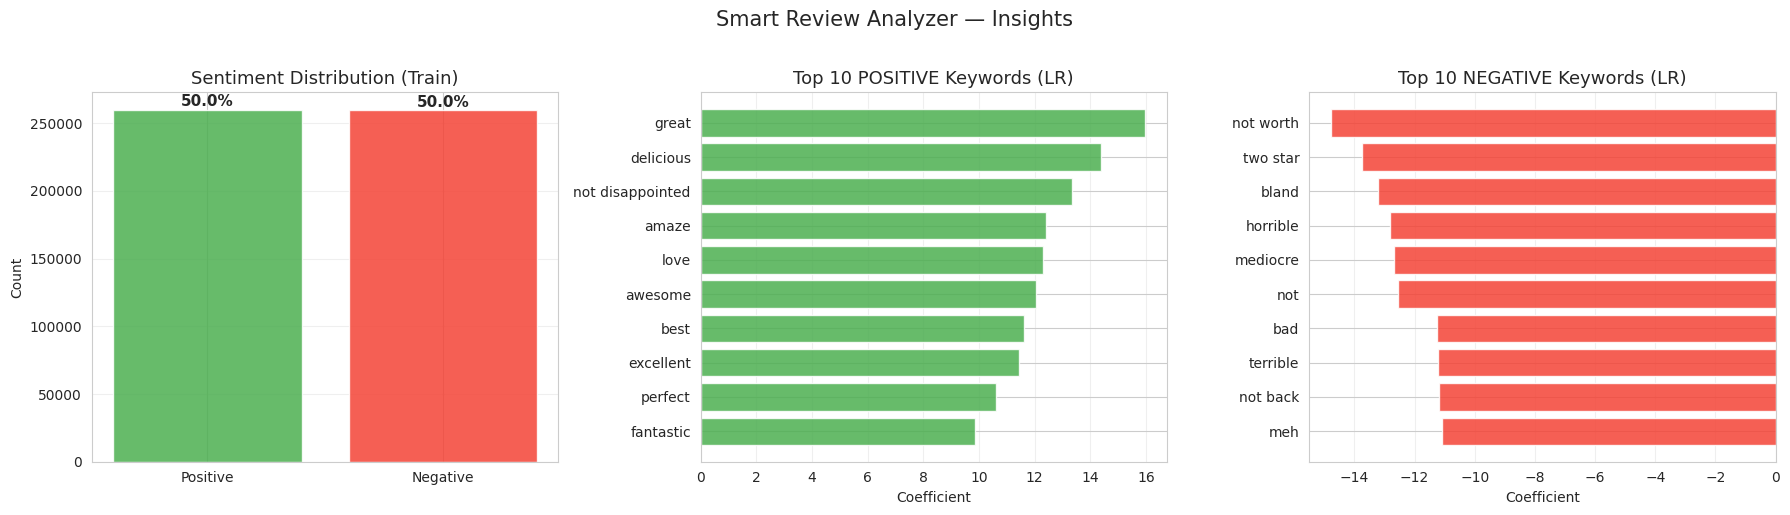

Saved → insights_overview.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Sentiment distribution
axes[0].bar(['Positive', 'Negative'], [pos_train, neg_train],
            color=['#4CAF50', '#F44336'], alpha=0.85, edgecolor='white')
axes[0].set_title('Sentiment Distribution (Train)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate([pos_train, neg_train]):
    axes[0].text(i, v + max(pos_train, neg_train)*0.01,
                 f'{v/total_train*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# (2) Top positive keywords
top10_pos = top_positive_words[:10]
top10_pos_c = lr_coefficients[top_pos_idx[:10]]
axes[1].barh(top10_pos[::-1], top10_pos_c[::-1], color='#4CAF50', alpha=0.85)
axes[1].set_title('Top 10 POSITIVE Keywords (LR)', fontsize=13)
axes[1].set_xlabel('Coefficient')
axes[1].grid(axis='x', alpha=0.3)

# (3) Top negative keywords
top10_neg = top_negative_words[:10]
top10_neg_c = lr_coefficients[top_neg_idx[:10]]
axes[2].barh(top10_neg[::-1], top10_neg_c[::-1], color='#F44336', alpha=0.85)
axes[2].set_title('Top 10 NEGATIVE Keywords (LR)', fontsize=13)
axes[2].set_xlabel('Coefficient')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Smart Review Analyzer — Insights', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/insights_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → insights_overview.png')

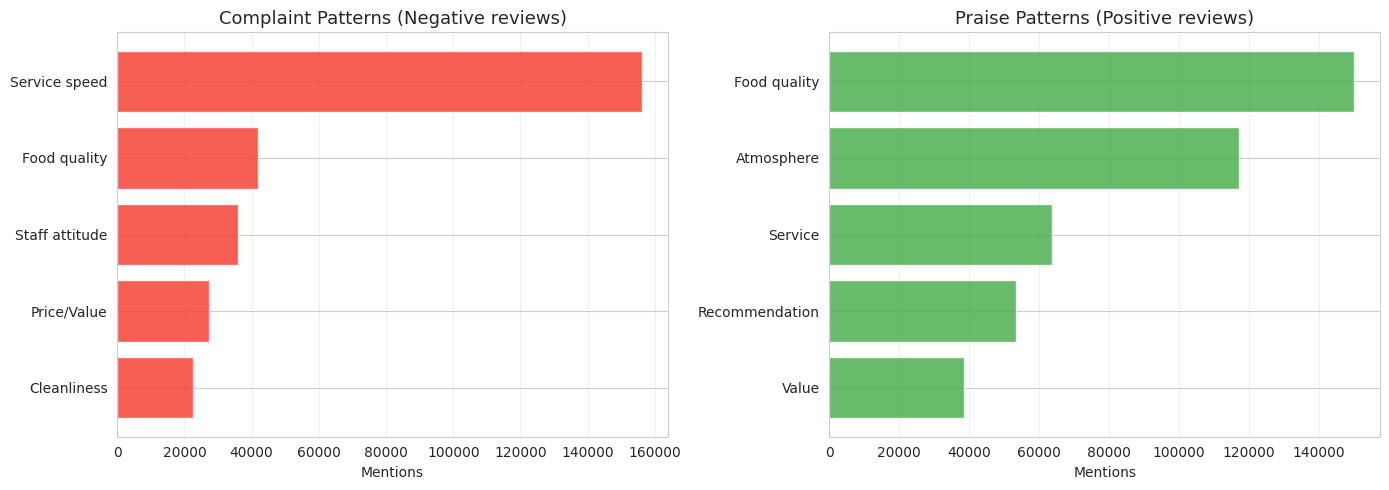

Saved → patterns.png


In [17]:
# Patterns side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neg_items = sorted(neg_pattern_counts.items(), key=lambda x: x[1])
axes[0].barh([k for k, _ in neg_items], [v for _, v in neg_items], color='#F44336', alpha=0.85)
axes[0].set_title('Complaint Patterns (Negative reviews)', fontsize=13)
axes[0].set_xlabel('Mentions')
axes[0].grid(axis='x', alpha=0.3)

pos_items = sorted(pos_pattern_counts.items(), key=lambda x: x[1])
axes[1].barh([k for k, _ in pos_items], [v for _, v in pos_items], color='#4CAF50', alpha=0.85)
axes[1].set_title('Praise Patterns (Positive reviews)', fontsize=13)
axes[1].set_xlabel('Mentions')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → patterns.png')

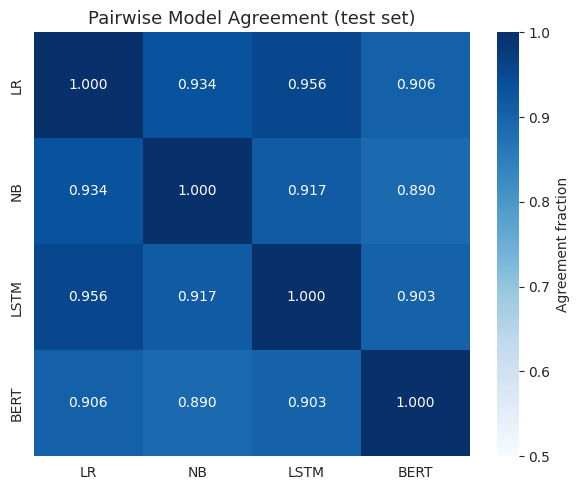

Saved → model_agreement.png


In [18]:
# Agreement heatmap
if agreement is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(agreement.astype(float), annot=True, fmt='.3f', cmap='Blues',
                vmin=0.5, vmax=1.0, cbar_kws={'label': 'Agreement fraction'}, ax=ax)
    ax.set_title('Pairwise Model Agreement (test set)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/model_agreement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → model_agreement.png')

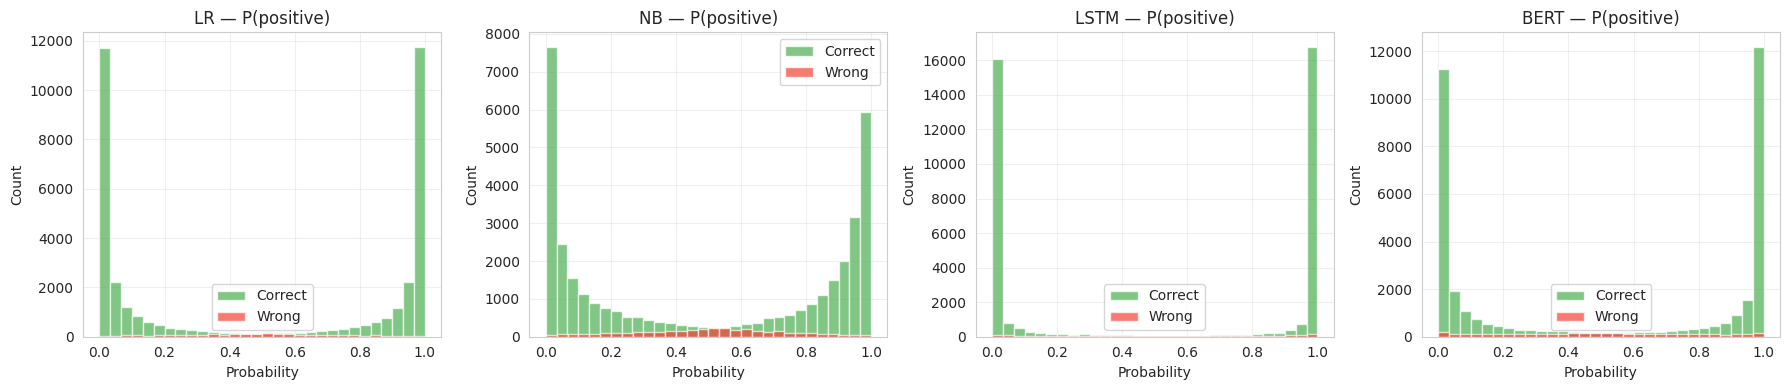

Saved → confidence_histograms.png


In [19]:
# Confidence histograms (one subplot per model)
if proba_sources:
    n = len(proba_sources)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
    for ax, (name, proba, pred) in zip(axes[0], proba_sources):
        if y_test is not None and pred is not None:
            correct = proba[pred == y_test]
            wrong   = proba[pred != y_test]
            ax.hist(correct, bins=30, alpha=0.7, label='Correct', color='#4CAF50')
            ax.hist(wrong,   bins=30, alpha=0.7, label='Wrong',   color='#F44336')
            ax.legend()
        else:
            ax.hist(proba, bins=30, color='#2196F3', alpha=0.85)
        ax.set_title(f'{name} — P(positive)', fontsize=12)
        ax.set_xlabel('Probability'); ax.set_ylabel('Count')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confidence_histograms.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → confidence_histograms.png')

## 12 · Sample Predictions — Side-by-Side Explanations

For each sample review, we show:
* The LR prediction with **per-word contribution** (the only interpretable model here)
* The NB prediction with confidence
* The LSTM and BERT predictions (if their re-inference assets are available)

For LSTM and BERT we re-run inference only if the assets are available — otherwise we skip those columns gracefully. Re-running LSTM requires the saved `word2vec.model` + the LSTM `.h5` checkpoint; re-running BERT requires the `sentence-transformers` package and network access to download `all-MiniLM-L6-v2`.

**Note on the pre-processing function:** to keep this notebook self-contained and identical to the upstream pipeline, we re-implement the same `preprocess()` used in earlier notebooks. If you change the pre-processing in the pipeline, change it here too.

In [20]:
!pip install -q contractions nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.1 MB/s eta 0:00:00


In [21]:
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f'  nltk download {pkg}: {e}')

In [22]:
import contractions, html
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

_LEMMA = WordNetLemmatizer()
_STOP  = set(stopwords.words('english')) - {'no', 'not', 'nor', 'never', 'very'}

def preprocess(text):
    text = contractions.fix(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in _STOP]
    return ' '.join(_LEMMA.lemmatize(t) for t in tokens)

print('preprocess() ready.')

preprocess() ready.


In [23]:
# ── Optional: build LSTM inference assets ──
# We only attempt this if (a) the gensim Word2Vec model is on disk and
# (b) the LSTM checkpoint is on disk. Anything missing → LSTM column skipped.

lstm_infer = None
lstm_w2idx = None
LSTM_MAXLEN = 256  # must match notebook 03

try:
    from gensim.models import Word2Vec
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    w2v_path = f'{FEATURES_DIR}/word2vec.model'
    lstm_path = f'{MODELS_DIR}/lstm_w2v_best.h5'
    if os.path.exists(w2v_path) and os.path.exists(lstm_path):
        w2v_model = Word2Vec.load(w2v_path)
        wv = w2v_model.wv
        lstm_w2idx = {w: i + 1 for i, w in enumerate(wv.index_to_key)}
        vocab_size_l = len(lstm_w2idx) + 1
        embed_dim_l  = wv.vector_size

        emb_mat = np.zeros((vocab_size_l, embed_dim_l), dtype=np.float32)
        for w, i in lstm_w2idx.items():
            emb_mat[i] = wv[w]

        # Rebuild the exact architecture from notebook 03
        inp = keras.Input(shape=(LSTM_MAXLEN,), name='token_ids')
        x   = layers.Embedding(vocab_size_l, embed_dim_l, weights=[emb_mat],
                               input_length=LSTM_MAXLEN, trainable=False,
                               name='w2v_embedding')(inp)
        x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True), name='bilstm_1')(x)
        x   = layers.Bidirectional(layers.LSTM(64), name='bilstm_2')(x)
        x   = layers.Dropout(0.3)(x)
        x   = layers.Dense(64, activation='relu')(x)
        x   = layers.Dropout(0.3)(x)
        out = layers.Dense(1, activation='sigmoid', name='output')(x)
        lstm_infer = keras.Model(inp, out)
        lstm_infer.load_weights(lstm_path)

        def lstm_predict(text_raw):
            cleaned = preprocess(text_raw)
            seq = [[lstm_w2idx[w] for w in cleaned.split() if w in lstm_w2idx]]
            seq = pad_sequences(seq, maxlen=LSTM_MAXLEN, padding='post', truncating='post')
            p   = float(lstm_infer.predict(seq, verbose=0).ravel()[0])
            return p, int(p >= 0.5)

        print('✓ LSTM inference assets ready.')
    else:
        print('LSTM assets missing — sample predictions will skip LSTM column.')
        def lstm_predict(text_raw): return None
except Exception as e:
    print(f'LSTM inference unavailable: {type(e).__name__}: {e}')
    def lstm_predict(text_raw): return None

LSTM inference unavailable: ModuleNotFoundError: No module named 'gensim'


In [32]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.0 MB/s eta 0:00:00


In [33]:
# ── Optional: build LSTM inference assets (robust version) ──
lstm_infer = None
lstm_w2idx = None
LSTM_MAXLEN = 256  # must match notebook 03

try:
    from gensim.models import Word2Vec
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    print(f'TF: {tf.__version__}, Keras: {keras.__version__}')

    w2v_path  = f'{FEATURES_DIR}/word2vec.model'
    lstm_path = f'{MODELS_DIR}/lstm_w2v_best.h5'
    assert os.path.exists(w2v_path),  f'W2V missing at {w2v_path}'
    assert os.path.exists(lstm_path), f'LSTM ckpt missing at {lstm_path}'

    w2v_model = Word2Vec.load(w2v_path)
    wv = w2v_model.wv
    lstm_w2idx = {w: i + 1 for i, w in enumerate(wv.index_to_key)}
    vocab_size_l = len(lstm_w2idx) + 1
    embed_dim_l  = wv.vector_size
    print(f'W2V vocab: {vocab_size_l:,}, embed_dim: {embed_dim_l}')

    emb_mat = np.zeros((vocab_size_l, embed_dim_l), dtype=np.float32)
    for w, i in lstm_w2idx.items():
        emb_mat[i] = wv[w]

    # Rebuild arch — note: NO input_length (deprecated in Keras 3, can cause mismatch)
    inp = keras.Input(shape=(LSTM_MAXLEN,), name='token_ids')
    x   = layers.Embedding(vocab_size_l, embed_dim_l,
                           weights=[emb_mat], trainable=False,
                           name='w2v_embedding')(inp)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True), name='bilstm_1')(x)
    x   = layers.Bidirectional(layers.LSTM(64), name='bilstm_2')(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    lstm_infer = keras.Model(inp, out)

    # Try several load strategies, in order of preference
    loaded_ok = False
    for strategy in ['plain', 'by_name', 'by_name_skip']:
        try:
            if strategy == 'plain':
                lstm_infer.load_weights(lstm_path)
            elif strategy == 'by_name':
                lstm_infer.load_weights(lstm_path, by_name=True)
            else:
                lstm_infer.load_weights(lstm_path, by_name=True, skip_mismatch=True)
            print(f'✓ LSTM weights loaded via strategy: {strategy}')
            loaded_ok = True
            break
        except Exception as e:
            print(f'  strategy "{strategy}" failed: {type(e).__name__}: {str(e)[:200]}')

    if not loaded_ok:
        # Last resort: load the full model object from the .h5 (architecture + weights)
        try:
            lstm_infer = keras.models.load_model(lstm_path, compile=False)
            print('✓ LSTM loaded as full model (keras.models.load_model).')
            loaded_ok = True
        except Exception as e:
            print(f'  load_model also failed: {type(e).__name__}: {str(e)[:300]}')

    if loaded_ok:
        def lstm_predict(text_raw):
            cleaned = preprocess(text_raw)
            seq = [[lstm_w2idx[w] for w in cleaned.split() if w in lstm_w2idx]]
            seq = pad_sequences(seq, maxlen=LSTM_MAXLEN, padding='post', truncating='post')
            p   = float(lstm_infer.predict(seq, verbose=0).ravel()[0])
            return p, int(p >= 0.5)
        print('✓ LSTM inference ready.')
    else:
        print('✗ Could not load LSTM weights by any strategy.')
        def lstm_predict(text_raw): return None

except Exception as e:
    import traceback
    print(f'LSTM inference unavailable: {type(e).__name__}: {e}')
    traceback.print_exc()
    def lstm_predict(text_raw): return None

TF: 2.20.0, Keras: 3.13.2
W2V vocab: 89,745, embed_dim: 300
✓ LSTM weights loaded via strategy: plain
✓ LSTM inference ready.


In [34]:
# ── Optional: build BERT inference assets ──
# Requires sentence-transformers + (first-run) network access.

bert_infer = None
sbert_model = None

try:
    bert_path = f'{MODELS_DIR}/bert_mlp_best.h5'
    if os.path.exists(bert_path):
        !pip install -q sentence-transformers
        from sentence_transformers import SentenceTransformer
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers

        sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

        # Rebuild the exact MLP from notebook 03
        BERT_HIDDEN_UNITS = [256, 128]
        BERT_DROPOUT = 0.3
        input_dim = sbert_model.get_sentence_embedding_dimension()  # 384
        inp = keras.Input(shape=(input_dim,), name='bert_embedding')
        x = inp
        for units in BERT_HIDDEN_UNITS:
            x = layers.Dense(units, activation='relu')(x)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(BERT_DROPOUT)(x)
        out = layers.Dense(1, activation='sigmoid', name='output')(x)
        bert_infer = keras.Model(inp, out)
        bert_infer.load_weights(bert_path)

        def bert_predict(text_raw):
            # all-MiniLM-L6-v2 is robust to lightly-pre-processed text; use raw for best semantics
            emb = sbert_model.encode([text_raw], normalize_embeddings=True)
            p   = float(bert_infer.predict(emb, verbose=0).ravel()[0])
            return p, int(p >= 0.5)
        print('✓ BERT inference assets ready.')
    else:
        print('BERT assets missing — sample predictions will skip BERT column.')
        def bert_predict(text_raw): return None
except Exception as e:
    print(f'BERT inference unavailable: {type(e).__name__}: {e}')
    def bert_predict(text_raw): return None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BERT inference assets ready.


In [35]:
def explain_one(text_raw):
    cleaned = preprocess(text_raw)
    vec = tfidf.transform([cleaned])

    # LR — word contributions
    lr_p = float(lr_tfidf.predict_proba(vec)[0, 1])
    lr_y = int(lr_p >= 0.5)
    vec_dense = vec.toarray()[0]
    contrib   = vec_dense * lr_coefficients
    top_idx   = np.argsort(np.abs(contrib))[-5:][::-1]
    top_words = [(feature_names[i], float(contrib[i])) for i in top_idx if vec_dense[i] > 0]

    # NB
    nb_p = nb_y = None
    if nb_tfidf is not None:
        nb_p = float(nb_tfidf.predict_proba(vec)[0, 1])
        nb_y = int(nb_p >= 0.5)

    # LSTM (optional)
    lstm_out = lstm_predict(text_raw)
    # BERT (optional)
    bert_out = bert_predict(text_raw)

    print('─' * 70)
    print(f'Review : {text_raw[:140]}')
    print(f'LR     : {"Positive" if lr_y==1 else "Negative":<9}  P(+) = {lr_p:.3f}')
    if nb_p is not None:
        print(f'NB     : {"Positive" if nb_y==1 else "Negative":<9}  P(+) = {nb_p:.3f}')
    if lstm_out is not None:
        lp, ly = lstm_out
        print(f'LSTM   : {"Positive" if ly==1 else "Negative":<9}  P(+) = {lp:.3f}')
    if bert_out is not None:
        bp, by = bert_out
        print(f'BERT   : {"Positive" if by==1 else "Negative":<9}  P(+) = {bp:.3f}')
    if top_words:
        print('Top LR-contributing words:')
        for w, s in top_words:
            direction = '→ Positive' if s > 0 else '→ Negative'
            print(f'    {w:<20s}  {direction}  ({s:+.4f})')


sample_reviews = [
    "The food was absolutely amazing and the service was so friendly!",
    "Worst experience ever. The waiter was rude and the food was cold.",
    "The service was slow but the pizza was decent.",
    "I would never come back. Disgusting place, dirty tables.",
    "Best restaurant in town! Highly recommend the pasta.",
    "Not bad, but not great either. Probably won't come back.",
]

print('═' * 70)
print('  SAMPLE PREDICTIONS — ALL MODELS')
print('═' * 70)
for r in sample_reviews:
    explain_one(r)

══════════════════════════════════════════════════════════════════════
  SAMPLE PREDICTIONS — ALL MODELS
══════════════════════════════════════════════════════════════════════
──────────────────────────────────────────────────────────────────────
Review : The food was absolutely amazing and the service was so friendly!
LR     : Positive   P(+) = 0.990
NB     : Positive   P(+) = 0.982
LSTM   : Positive   P(+) = 1.000
BERT   : Positive   P(+) = 1.000
Top LR-contributing words:
    amazing               → Positive  (+2.2904)
    friendly              → Positive  (+1.3712)
    absolutely amazing    → Positive  (+0.6264)
    absolutely            → Positive  (+0.4079)
    food absolutely       → Positive  (+0.3836)
──────────────────────────────────────────────────────────────────────
Review : Worst experience ever. The waiter was rude and the food was cold.
LR     : Negative   P(+) = 0.000
NB     : Negative   P(+) = 0.000
LSTM   : Negative   P(+) = 0.000
BERT   : Negative   P(+) = 0.000
To

## 13 · Export Dashboard Stats (JSON)

In [36]:
insights = {
    'sentiment_ratio': {
        'Positive': pos_train,
        'Negative': neg_train,
        'Total'   : total_train,
    },
    'top_positive_keywords': [
        {'word': str(w), 'coef': float(lr_coefficients[i])}
        for w, i in zip(top_positive_words, top_pos_idx)
    ],
    'top_negative_keywords': [
        {'word': str(w), 'coef': float(lr_coefficients[i])}
        for w, i in zip(top_negative_words, top_neg_idx)
    ],
    'complaint_patterns': {k: int(v) for k, v in neg_pattern_counts.items()},
    'praise_patterns':    {k: int(v) for k, v in pos_pattern_counts.items()},
    'review_length_by_class': {
        'Negative': {k: float(v) for k, v in length_stats.loc['Negative'].to_dict().items()},
        'Positive': {k: float(v) for k, v in length_stats.loc['Positive'].to_dict().items()},
    },
    'models_loaded': models_available,
}

if agreement is not None:
    insights['model_agreement'] = {a: {b: float(agreement.loc[a, b]) for b in agreement.columns}
                                   for a in agreement.index}

out_json = f'{OUTPUT_DIR}/dashboard_stats.json'
with open(out_json, 'w') as f:
    json.dump(insights, f, indent=2)
print(f'Saved → {out_json}')

# Also save a clean CSV of the top keywords for quick reference
kw_df = pd.DataFrame({
    'positive_word' : top_positive_words,
    'positive_coef' : lr_coefficients[top_pos_idx].round(4),
    'negative_word' : top_negative_words,
    'negative_coef' : lr_coefficients[top_neg_idx].round(4),
})
kw_df.to_csv(f'{OUTPUT_DIR}/top_keywords.csv', index=False)
print(f'Saved → {OUTPUT_DIR}/top_keywords.csv')

Saved → /content/drive/MyDrive/SmartReviewAnalyzer/models/insights/dashboard_stats.json
Saved → /content/drive/MyDrive/SmartReviewAnalyzer/models/insights/top_keywords.csv
